# Phase 2 — Two species + RD fields + killing

Three checks that each ingredient works in isolation, then a single full-model run.

* **2.1** T cells chemotax up a *frozen* attractant gradient.
* **2.2** Many T cells eat a small tumor (no proliferation).
* **2.3** A short full-physics run with both species, fields, killing, and proliferation.

In [1]:
import sys, pathlib
# robust root resolution: walk up until we find src/
ROOT = pathlib.Path().resolve()
while not (ROOT / 'src').is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import EllipseCollection
from scipy.ndimage import gaussian_filter

from src import style
from src.sim import SimParams, run, init_two_species, _step_particles_two_species
from src.fields import static_gaussian_field

style.apply_style()
print('imports OK')

imports OK


## 2.1  Chemotaxis to a static source

Pre-bake a Gaussian attractant centered in a 60×60 box and let 200 T cells (no tumor present)
evolve under chemotaxis + self-propulsion + repulsion. The attractant doesn't get updated, so
any aggregation must be driven by the chemotactic gradient alone.

In [2]:
p = SimParams(L=60.0, G=64, T_final=80.0,
              v_I=0.5, D_R_I=0.3,
              chi_a=20.0, chi_s=0.0,
              N_T_initial=0, N_I_initial=200,
              N_T_max=8, N_I_max=256, p_div=0.0)
np.random.seed(0)
state = init_two_species(p, seed=0)
pos_T, theta_T, alive_T = state['pos_T'], state['theta_T'], state['alive_T']
pos_I, theta_I, alive_I = state['pos_I'], state['theta_I'], state['alive_I']
c_a = static_gaussian_field(p.L, p.G, p.L/2, p.L/2, sig=5.0, amp=20.0)
c_s = np.zeros((p.G, p.G))
initial_xy = pos_I[alive_I].copy()
for _ in range(p.n_steps):
    _step_particles_two_species(
        pos_T, theta_T, alive_T, pos_I, theta_I, alive_I, c_a, c_s,
        p.dt, p.v_T, p.v_I, p.D_R_T, p.D_R_I, p.D_T_T, p.D_T_I,
        p.sigma_T, p.k_rep_T, p.sigma_I, p.k_rep_I, p.sigma_TI, p.k_rep_TI, p.L,
        p.chi_a, p.chi_s, p.r_kill, 0.0, 0.0, p.nbr_radius, p.nbr_threshold)
final_xy = pos_I[alive_I].copy()
print(f't = 0:  median r from center = {np.median(np.linalg.norm(initial_xy - p.L/2, axis=1)):.1f}')
print(f't = {p.T_final:.0f}: median r from center = {np.median(np.linalg.norm(final_xy - p.L/2, axis=1)):.1f}')

t = 0:  median r from center = 24.4
t = 80: median r from center = 12.6


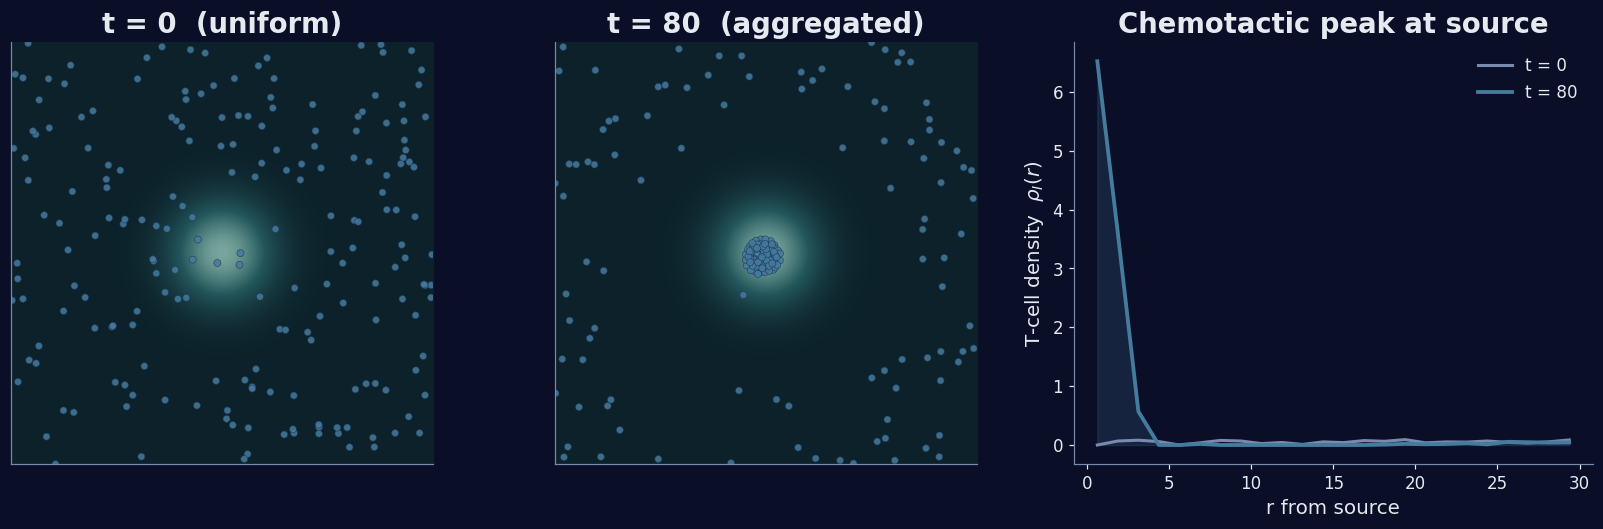

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=110,
                          gridspec_kw={'width_ratios':[1,1,1.1]})
fig.patch.set_facecolor(style.BG)
for ax, xy, title in zip(
        axes[:2], [initial_xy, final_xy],
        ['t = 0  (uniform)', f't = {p.T_final:.0f}  (aggregated)']):
    ax.set_facecolor(style.BG)
    ax.imshow(gaussian_filter(c_a, 0.6), extent=[0, p.L, 0, p.L], origin='lower',
               cmap=style.ATTRACTANT_CMAP, alpha=style.FIELD_ALPHA, interpolation='bilinear')
    ax.add_collection(EllipseCollection(
        widths=np.full(len(xy), 1.0), heights=np.full(len(xy), 1.0),
        angles=np.zeros(len(xy)), units='x', offsets=xy,
        transOffset=ax.transData,
        facecolors=style.TCELL, edgecolors=style.TCELL_EDGE,
        linewidths=0.4, alpha=style.PARTICLE_ALPHA))
    ax.set_xlim(0, p.L); ax.set_ylim(0, p.L)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, color=style.FG)

ax = axes[2]; ax.set_facecolor(style.BG)
center = np.array([p.L/2, p.L/2])
r_edges = np.linspace(0, p.L/2, 25)
r_c = 0.5*(r_edges[:-1] + r_edges[1:])
areas = np.pi*(r_edges[1:]**2 - r_edges[:-1]**2)
for xy, lab, col, lw in [
        (initial_xy, 't = 0', style.MUTED, 2.0),
        (final_xy,   f't = {p.T_final:.0f}', style.TCELL, 2.5)]:
    d = np.linalg.norm(xy - center, axis=1)
    h, _ = np.histogram(d, bins=r_edges)
    ax.plot(r_c, h/areas, color=col, lw=lw, label=lab)
ax.fill_between(r_c, 0, np.histogram(np.linalg.norm(final_xy - center, axis=1), bins=r_edges)[0]/areas,
                 color=style.TCELL, alpha=0.2)
ax.set_xlabel('r from source'); ax.set_ylabel(r'T-cell density  $\rho_I(r)$')
ax.legend(frameon=False); ax.set_title('Chemotactic peak at source', color=style.FG)
plt.tight_layout()

**Reading the figure:** 200 T cells start uniformly across the box and end up packed at the
Gaussian source. The radial density jumps from a flat ~0.1 to a spike ~5–6 near r = 0. ✓

## 2.2  Small tumor + many T cells — killing in isolation

Place 50 tumor cells in a tight disk, surround with 200 T cells, **disable proliferation** so
the only dynamics are: T cells find the tumor, T cells kill on contact. Tumor count should
drop to zero in tens of time units.

In [4]:
p = SimParams(L=60.0, G=64, T_final=40.0,
              chi_a=10.0, chi_s=0.0,
              N_T_initial=50, N_I_initial=200, tumor_disk_radius=4.0,
              p_div=0.0,                    # killing-only test
              r_kill=1.5, p_kill=0.1,
              N_T_max=128, N_I_max=256)
out = run(rho_I=200, alpha=0.0, seed=1, params=p)
print(f'final N_T = {out.n_T[-1]} (started 50), T_final fraction = {out.final_tumor_fraction:.3f}')

final N_T = 0 (started 50), T_final fraction = 0.010


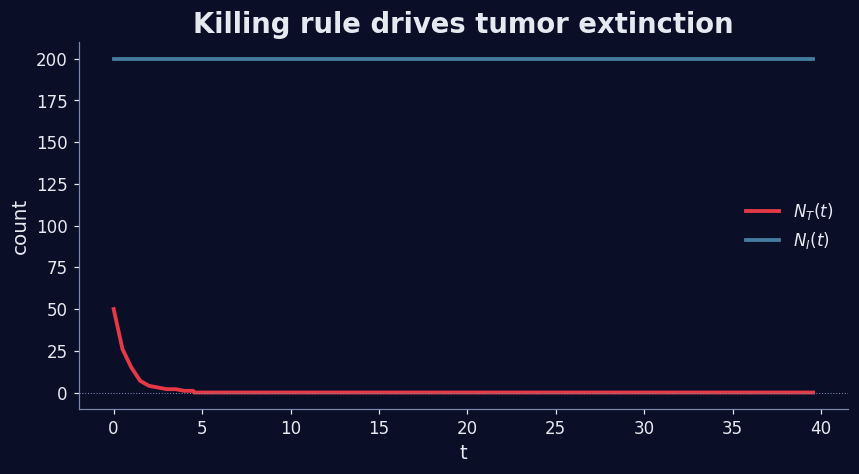

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=110)
fig.patch.set_facecolor(style.BG); ax.set_facecolor(style.BG)
t = np.asarray(out.times)
ax.plot(t, out.n_T, color=style.TUMOR, lw=2.5, label=r'$N_T(t)$')
ax.plot(t, out.n_I, color=style.TCELL, lw=2.5, label=r'$N_I(t)$')
ax.axhline(0, color=style.MUTED, lw=0.7, ls=':')
ax.set_xlabel('t'); ax.set_ylabel('count')
ax.set_title('Killing rule drives tumor extinction', color=style.FG)
ax.legend(frameon=False)
plt.tight_layout()

**Reading the figure:** the red curve is the tumor count; it drops to 0 within ~10 time units.
T cells stay at 200 throughout — no proliferation, no death. ✓

## 2.3  Full model: one representative run

Now everything is on at once: tumor proliferation, T-cell chemotaxis up the attractant, away
from the suppressant, killing, repulsion. We're sampling a control / boundary point
(ρ_I=229, α=3.57) where the dynamics are interesting — the tumor and immune response are
roughly balanced. Reusing the same seed that produced the slide-3 thumbnail.

In [6]:
p = SimParams()   # defaults
out = run(rho_I=229, alpha=3.57, seed=1, params=p, snapshot_every=200)
print(f'final N_T = {out.n_T[-1]},  final N_I = {out.n_I[-1]}')
print(f'final tumor fraction (capped) = {out.final_tumor_fraction:.2f}')

final N_T = 0,  final N_I = 229
final tumor fraction (capped) = 0.01


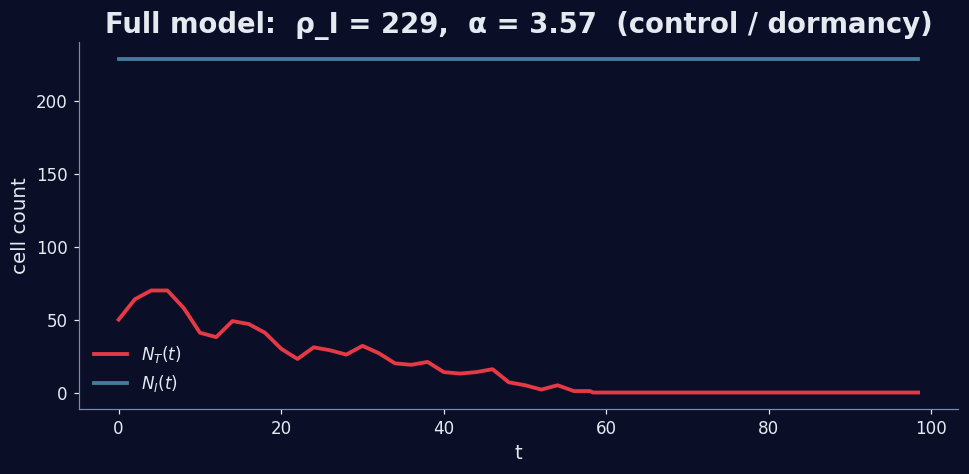

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
fig.patch.set_facecolor(style.BG); ax.set_facecolor(style.BG)
t = np.asarray(out.times)
ax.plot(t, out.n_T, color=style.TUMOR, lw=2.5, label=r'$N_T(t)$')
ax.plot(t, out.n_I, color=style.TCELL, lw=2.5, label=r'$N_I(t)$')
ax.set_xlabel('t'); ax.set_ylabel('cell count')
ax.set_title('Full model:  ρ_I = 229,  α = 3.57  (control / dormancy)', color=style.FG)
ax.legend(frameon=False)
plt.tight_layout()

**Reading the figure:** the tumor curve sits in a dormant band of ~50–100 cells for most of
the run. This is the 'control' phase — what the spec called dormancy. Phase 3 sweeps this
two-parameter space to map where each phase lives.